In [ ]:
# Step 1: Import required libraries and load dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
file_path = "/content/Stock_Price_Data.csv"
df = pd.read_csv(file_path)

# Display first five rows
print("First 5 rows of dataset:")
display(df.head())

# Display dataset information
print("\nDataset Information:")
df.info()

# Display dataset shape
print("\nDataset Shape:")
print(df.shape)

First 5 rows of dataset:


,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.513393,0.515625,0.513393,0.513393,0.406782,117258400
1,1980-12-15,0.488839,0.488839,0.486607,0.486607,0.385558,43971200
2,1980-12-16,0.453125,0.453125,0.450893,0.450893,0.357260,26432000
3,1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366103,21610400
4,1980-12-18,0.475446,0.477679,0.475446,0.475446,0.376715,18362400



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9909 entries, 0 to 9908
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       9909 non-null   object 
 1   Open       9909 non-null   float64
 2   High       9909 non-null   float64
 3   Low        9909 non-null   float64
 4   Close      9909 non-null   float64
 5   Adj Close  9909 non-null   float64
 6   Volume     9909 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 542.0+ KB

Dataset Shape:
(9909, 7)


Missing Values:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Duplicate Rows: 0

First 5 rows after preprocessing:


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1980-12-12,0.513393,0.515625,0.513393,0.513393,0.406782,117258400
1980-12-15,0.488839,0.488839,0.486607,0.486607,0.385558,43971200
1980-12-16,0.453125,0.453125,0.450893,0.450893,0.357260,26432000
1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366103,21610400
1980-12-18,0.475446,0.477679,0.475446,0.475446,0.376715,18362400



Summary Statistics:


,Open,High,Low,Close,Adj Close,Volume
count,9909.000000,9909.000000,9909.000000,9909.000000,9909.000000,9.909000e+03
mean,32.606849,32.936079,32.277560,32.618030,30.576570,8.582916e+07
std,58.415759,59.001576,57.883037,58.471899,56.746275,8.597195e+07
min,0.198661,0.198661,0.196429,0.196429,0.155638,3.472000e+05
25%,1.071429,1.089286,1.048571,1.071429,0.917643,3.304230e+07
50%,1.729286,1.758929,1.696429,1.732143,1.466154,5.766490e+07
75%,35.799999,36.265713,35.328571,35.761429,31.042374,1.069992e+08
max,324.739990,327.850006,323.350006,327.200012,327.200012,1.855410e+09


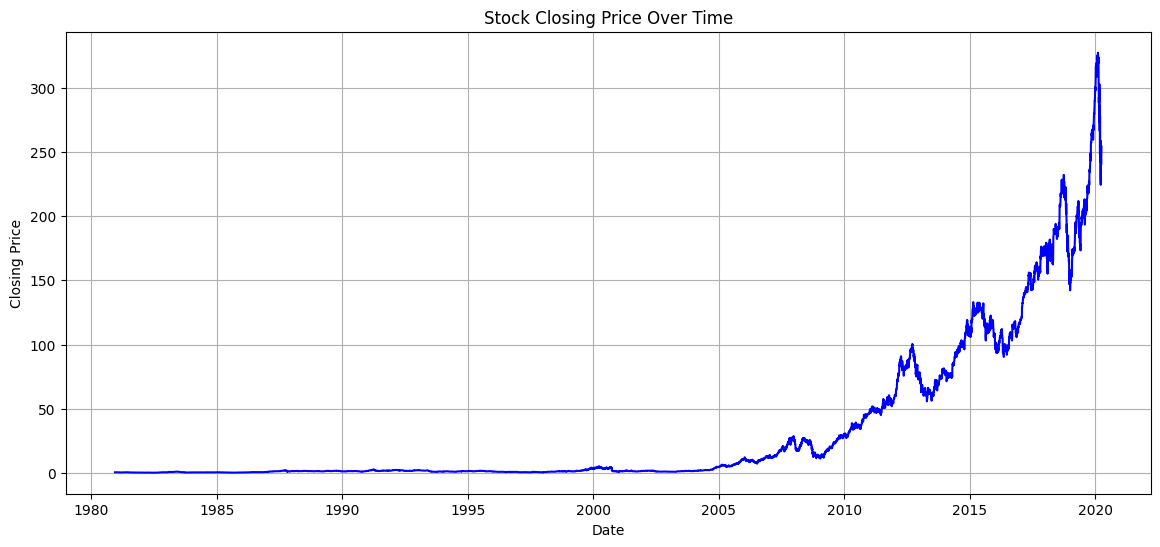

In [2]:
# Step 2: Data Exploration & Preprocessing

# Check missing values
print("Missing Values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Sort dataset by Date
df = df.sort_values("Date")

# Set Date as index
df.set_index("Date", inplace=True)

# Display first five rows after preprocessing
print("\nFirst 5 rows after preprocessing:")
display(df.head())

# Summary statistics
print("\nSummary Statistics:")
display(df.describe())

# Plot Closing Price
plt.figure(figsize=(14,6))
plt.plot(df["Close"], color="blue")
plt.title("Stock Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.grid(True)
plt.show()

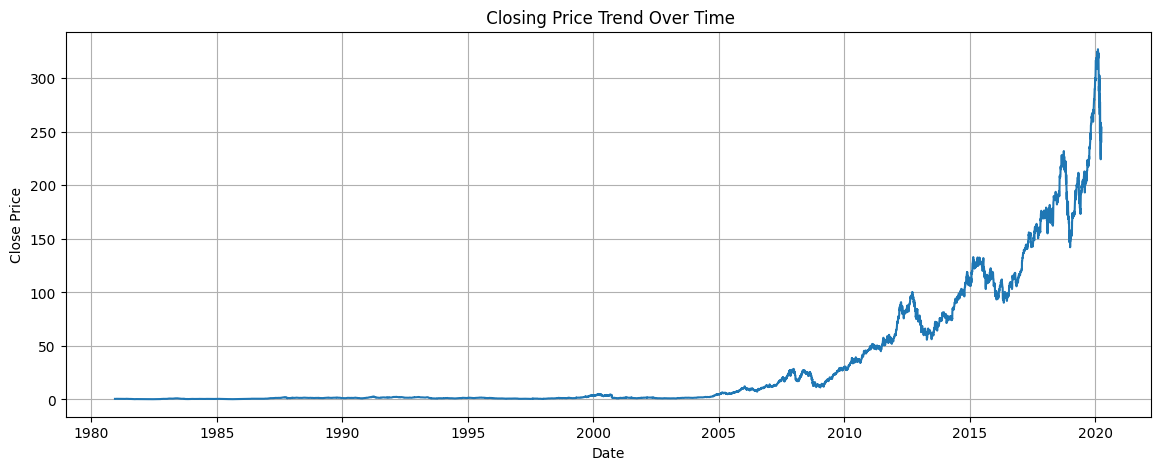

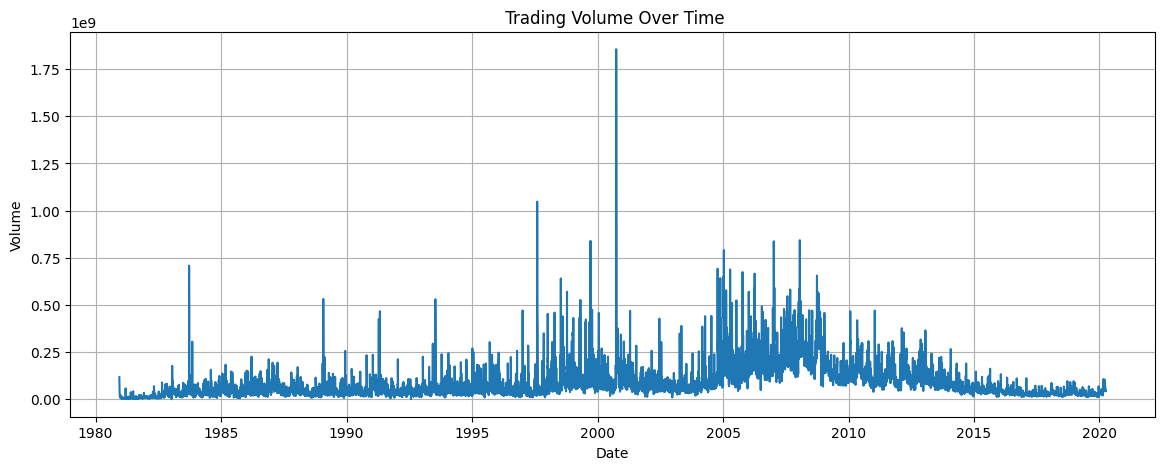

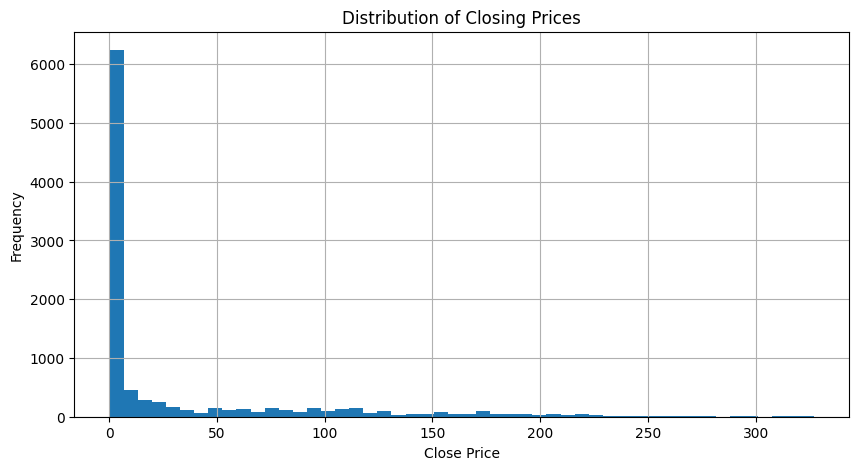

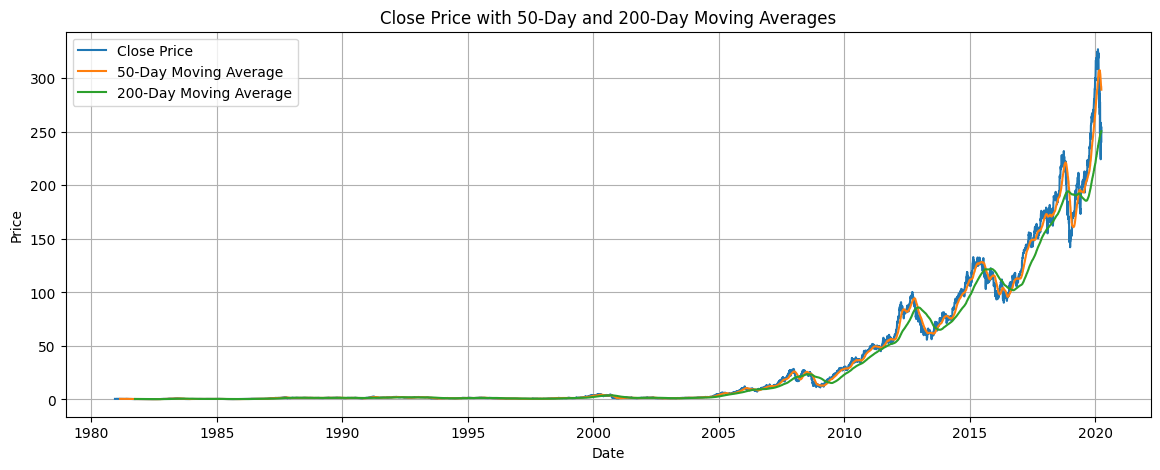

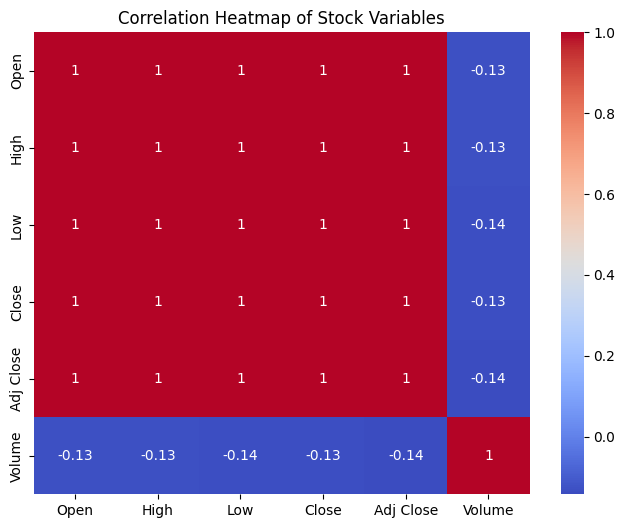

In [5]:
# 5 Useful EDA Analyses in One Cell

import matplotlib.pyplot as plt
import seaborn as sns

# Ensure Date index is correct
df = df.sort_index()

# 1. Closing price trend
plt.figure(figsize=(14,5))
plt.plot(df.index, df["Close"])
plt.title(" Closing Price Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.grid(True)
plt.show()

# 2. Trading volume trend
plt.figure(figsize=(14,5))
plt.plot(df.index, df["Volume"])
plt.title(" Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.grid(True)
plt.show()

# 3. Distribution of closing price
plt.figure(figsize=(10,5))
plt.hist(df["Close"], bins=50)
plt.title("Distribution of Closing Prices")
plt.xlabel("Close Price")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# 4. Moving averages with closing price
df["MA_50"] = df["Close"].rolling(window=50).mean()
df["MA_200"] = df["Close"].rolling(window=200).mean()

plt.figure(figsize=(14,5))
plt.plot(df.index, df["Close"], label="Close Price")
plt.plot(df.index, df["MA_50"], label="50-Day Moving Average")
plt.plot(df.index, df["MA_200"], label="200-Day Moving Average")
plt.title("Close Price with 50-Day and 200-Day Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

# 5. Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[["Open", "High", "Low", "Close", "Adj Close", "Volume"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Stock Variables")
plt.show()

In [3]:
# Step 3: Feature Selection and Scaling

from sklearn.preprocessing import MinMaxScaler

# Select only the Close price for prediction
close_data = df[["Close"]].values

# Apply MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(close_data)

# Display shape and sample values
print("Original Close Data Shape:", close_data.shape)
print("Scaled Data Shape:", scaled_data.shape)

print("\nFirst 5 original Close values:")
print(close_data[:5])

print("\nFirst 5 scaled Close values:")
print(scaled_data[:5])

Original Close Data Shape: (9909, 1)
Scaled Data Shape: (9909, 1)

First 5 original Close values:
[[0.51339287]
 [0.48660713]
 [0.45089287]
 [0.46205357]
 [0.47544643]]

First 5 scaled Close values:
[[0.0009693 ]
 [0.00088739]
 [0.00077817]
 [0.0008123 ]
 [0.00085326]]


In [6]:
# Step 4: Create time-series sequences and train-test split

sequence_length = 60

X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

# Reshape X for LSTM/GRU: samples, time steps, features
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# Train-test split: 80% training, 20% testing
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
y_train = y[:train_size]

X_test = X[train_size:]
y_test = y[train_size:]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X shape: (9849, 60, 1)
y shape: (9849,)
X_train shape: (7879, 60, 1)
y_train shape: (7879,)
X_test shape: (1970, 60, 1)
y_test shape: (1970,)


In [7]:
# Step 5: Build and Train LSTM Model

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Set seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Build LSTM model
lstm_model = Sequential()

lstm_model.add(LSTM(units=64, return_sequences=True, input_shape=(X_train.shape[1], 1)))
lstm_model.add(Dropout(0.2))

lstm_model.add(LSTM(units=32, return_sequences=False))
lstm_model.add(Dropout(0.2))

lstm_model.add(Dense(units=1))

# Compile model
lstm_model.compile(optimizer="adam", loss="mean_squared_error")

# Display model summary
print("LSTM Model Summary:")
lstm_model.summary()

# Early stopping
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# Train model
lstm_history = lstm_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


LSTM Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 6.2734e-06 - val_loss: 3.4245e-05
Epoch 2/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 9.6156e-07 - val_loss: 2.2752e-04
Epoch 3/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 9.7093e-07 - val_loss: 8.9304e-05
Epoch 4/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 8.7293e-07 - val_loss: 6.5178e-05
Epoch 5/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 9.2490e-07 - val_loss: 2.9002e-05
Epoch 6/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 7.7492e-07 - val_loss: 4.9428e-05
Epoch 7/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 7.3682e-07 - val_loss: 2.6592e-05
Epoch 8/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 6.8057e-07 - val_loss: 7.3528e-05
Epoch 9/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 6.3891e-07 - val_loss: 5.6767e-05
Epoch 10/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 7.2554e-07 - val_loss: 1.6402e-05
Epoch 11/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/

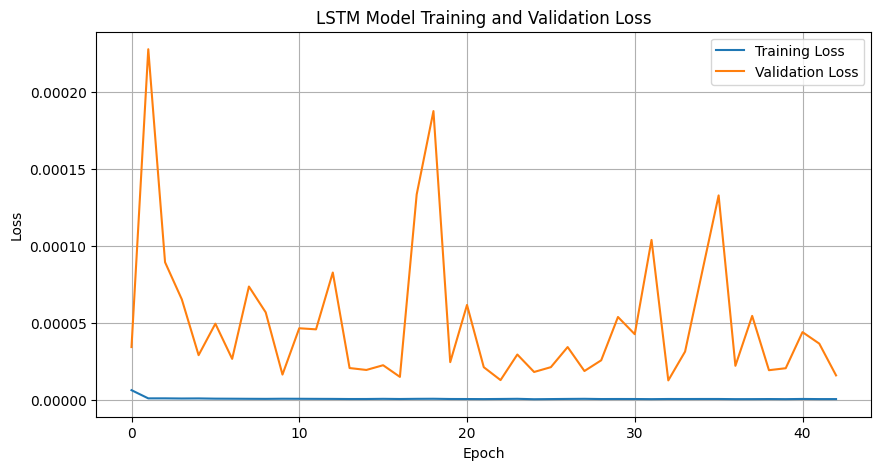

Best LSTM Validation Loss: 1.2618333130376413e-05
Final LSTM Training Loss: 4.919445473205997e-07
Final LSTM Validation Loss: 1.586981670698151e-05


In [8]:
# Step 6: Plot LSTM Training and Validation Loss

plt.figure(figsize=(10,5))
plt.plot(lstm_history.history["loss"], label="Training Loss")
plt.plot(lstm_history.history["val_loss"], label="Validation Loss")
plt.title("LSTM Model Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# Print best and final validation loss
print("Best LSTM Validation Loss:", min(lstm_history.history["val_loss"]))
print("Final LSTM Training Loss:", lstm_history.history["loss"][-1])
print("Final LSTM Validation Loss:", lstm_history.history["val_loss"][-1])

In [9]:
# Step 7: Build and Train GRU Model

from tensorflow.keras.layers import GRU

# Set seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Build GRU model
gru_model = Sequential()

gru_model.add(GRU(units=64, return_sequences=True, input_shape=(X_train.shape[1], 1)))
gru_model.add(Dropout(0.2))

gru_model.add(GRU(units=32, return_sequences=False))
gru_model.add(Dropout(0.2))

gru_model.add(Dense(units=1))

# Compile model
gru_model.compile(optimizer="adam", loss="mean_squared_error")

# Display model summary
print("GRU Model Summary:")
gru_model.summary()

# Early stopping
early_stop_gru = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# Train GRU model
gru_history = gru_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop_gru],
    verbose=1
)

GRU Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 60, 64)         │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,305 (87.13 KB)

 Trainable params: 22,305 (87.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 1.0818e-05 - val_loss: 1.2910e-05
Epoch 2/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.2394e-06 - val_loss: 1.4607e-05
Epoch 3/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.2329e-06 - val_loss: 5.5624e-05
Epoch 4/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 9.1616e-07 - val_loss: 1.1804e-05
Epoch 5/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 7.3509e-07 - val_loss: 1.4342e-05
Epoch 6/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 9.5201e-07 - val_loss: 9.7073e-06
Epoch 7/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 8.2024e-07 - val_loss: 7.8793e-05
Epoch 8/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 8.5810e-07 - val_loss: 3.8192e-05
Epoch 9/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 9.1884e-07 - val_loss: 1.3289e-05
Epoch 10/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 7.5832e-07 - val_loss: 2.3797e-05
Epoch 11/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/

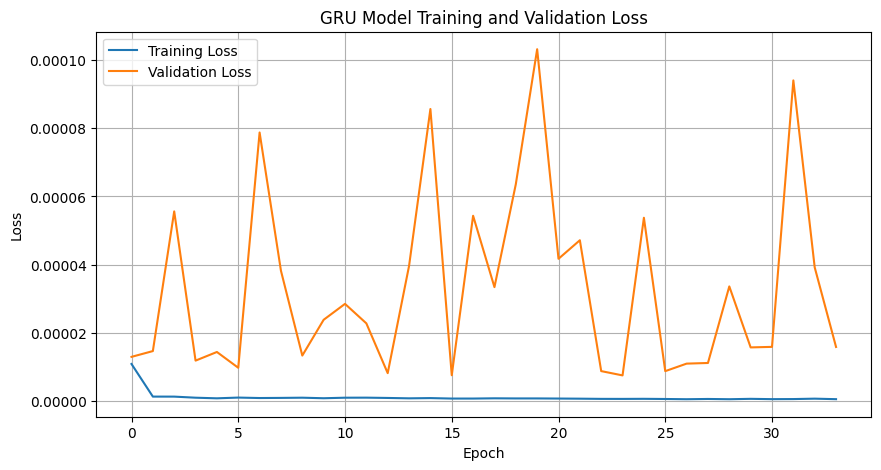

Best GRU Validation Loss: 7.462981557182502e-06
Final GRU Training Loss: 4.840895826419e-07
Final GRU Validation Loss: 1.5815801816643216e-05


In [10]:
# Step 8: Plot GRU Training History

plt.figure(figsize=(10,5))
plt.plot(gru_history.history["loss"], label="Training Loss")
plt.plot(gru_history.history["val_loss"], label="Validation Loss")

plt.title("GRU Model Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

print("Best GRU Validation Loss:", min(gru_history.history["val_loss"]))
print("Final GRU Training Loss:", gru_history.history["loss"][-1])
print("Final GRU Validation Loss:", gru_history.history["val_loss"][-1])

62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


,Model,MAE,MSE,RMSE,R2 Score,Best Validation Loss,Parameters
0,LSTM,6.998304,128.140577,11.319919,0.961583,0.000013,29345
1,GRU,2.965330,22.639700,4.758119,0.993213,0.000007,22305


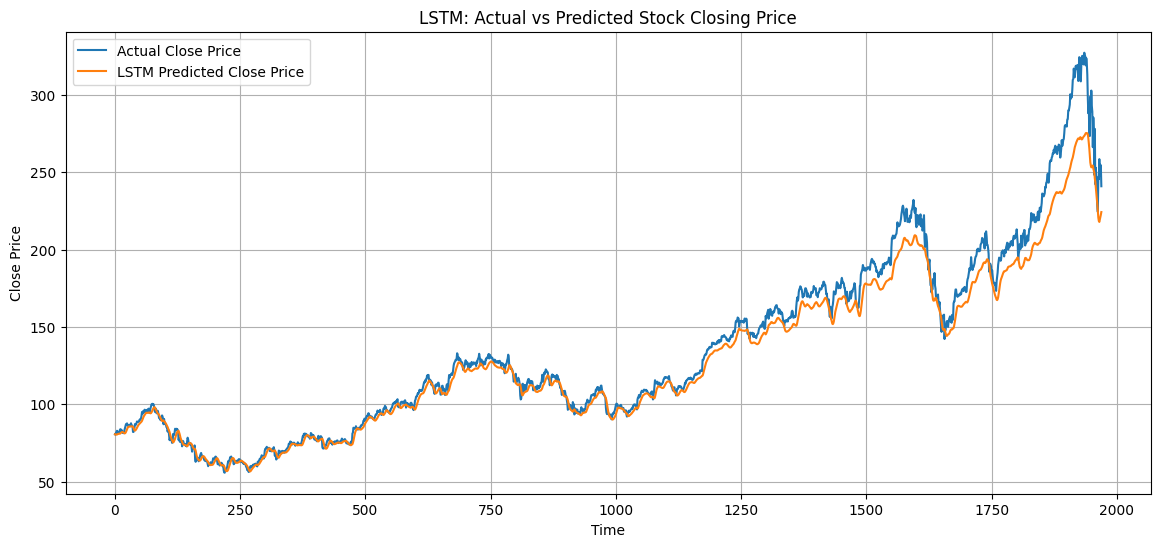

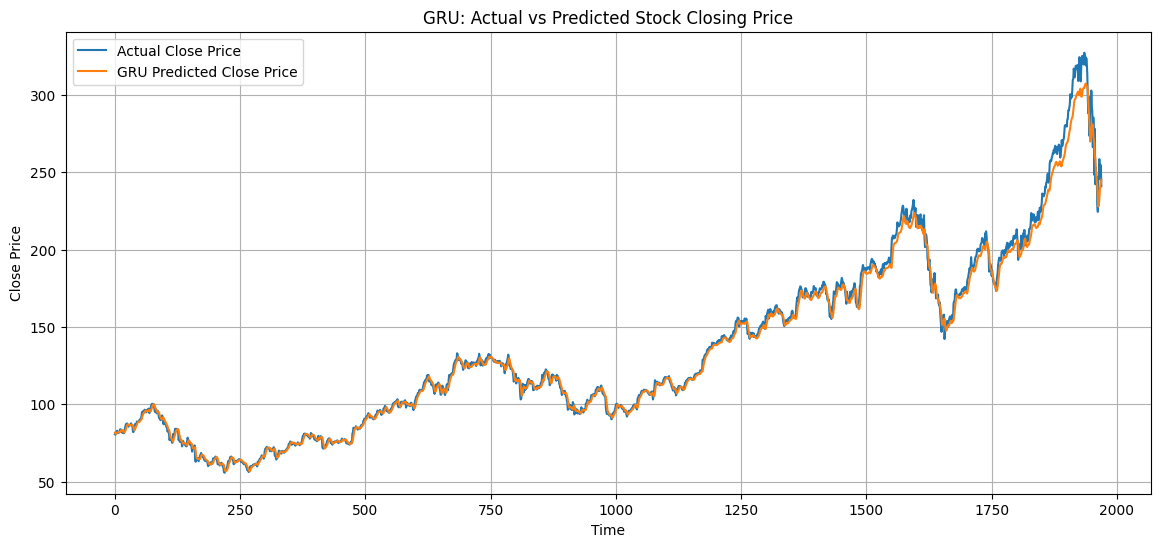

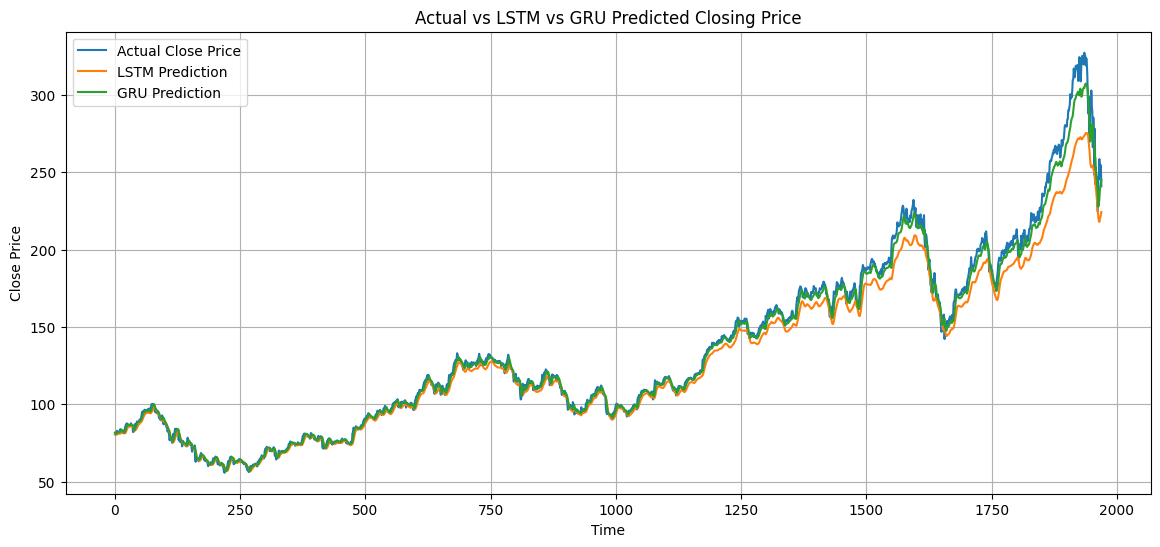

In [11]:
# Step 9: Model Evaluation and Prediction Comparison

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make predictions
lstm_pred_scaled = lstm_model.predict(X_test)
gru_pred_scaled = gru_model.predict(X_test)

# Inverse transform predictions and actual values
lstm_pred = scaler.inverse_transform(lstm_pred_scaled)
gru_pred = scaler.inverse_transform(gru_pred_scaled)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Evaluation function
def evaluate_model(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    r2 = r2_score(actual, predicted)
    return mae, mse, rmse, r2

# Evaluate both models
lstm_mae, lstm_mse, lstm_rmse, lstm_r2 = evaluate_model(y_test_actual, lstm_pred)
gru_mae, gru_mse, gru_rmse, gru_r2 = evaluate_model(y_test_actual, gru_pred)

# Create comparison table
results = pd.DataFrame({
    "Model": ["LSTM", "GRU"],
    "MAE": [lstm_mae, gru_mae],
    "MSE": [lstm_mse, gru_mse],
    "RMSE": [lstm_rmse, gru_rmse],
    "R2 Score": [lstm_r2, gru_r2],
    "Best Validation Loss": [
        min(lstm_history.history["val_loss"]),
        min(gru_history.history["val_loss"])
    ],
    "Parameters": [
        lstm_model.count_params(),
        gru_model.count_params()
    ]
})

display(results)

# Plot actual vs predicted for LSTM
plt.figure(figsize=(14,6))
plt.plot(y_test_actual, label="Actual Close Price")
plt.plot(lstm_pred, label="LSTM Predicted Close Price")
plt.title("LSTM: Actual vs Predicted Stock Closing Price")
plt.xlabel("Time")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)
plt.show()

# Plot actual vs predicted for GRU
plt.figure(figsize=(14,6))
plt.plot(y_test_actual, label="Actual Close Price")
plt.plot(gru_pred, label="GRU Predicted Close Price")
plt.title("GRU: Actual vs Predicted Stock Closing Price")
plt.xlabel("Time")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)
plt.show()

# Combined comparison plot
plt.figure(figsize=(14,6))
plt.plot(y_test_actual, label="Actual Close Price")
plt.plot(lstm_pred, label="LSTM Prediction")
plt.plot(gru_pred, label="GRU Prediction")
plt.title("Actual vs LSTM vs GRU Predicted Closing Price")
plt.xlabel("Time")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)
plt.show()

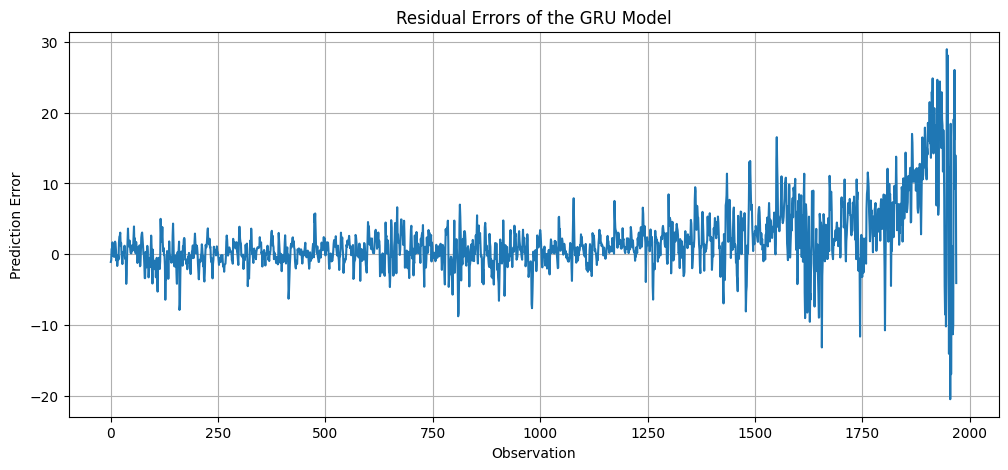

Residual Mean: 1.8044465505532201
Residual Std: 4.402689289439325


In [12]:
# Residual Analysis

residuals = y_test_actual.flatten() - gru_pred.flatten()

plt.figure(figsize=(12,5))
plt.plot(residuals)
plt.title("Residual Errors of the GRU Model")
plt.xlabel("Observation")
plt.ylabel("Prediction Error")
plt.grid(True)
plt.show()

print("Residual Mean:", residuals.mean())
print("Residual Std:", residuals.std())

In [14]:
results.to_csv("Model_Comparison.csv", index=False)

print(results)

  Model       MAE         MSE       RMSE  R2 Score  Best Validation Loss  \
0  LSTM  6.998304  128.140577  11.319919  0.961583              0.000013   
1   GRU  2.965330   22.639700   4.758119  0.993213              0.000007   

   Parameters  
0       29345  
1       22305  
